# **TRANSFERENCIA DE ESTILO CON CNN**

1. Descarga y preparación del dataset WikiArt (5 estilos)
2. DataLoader con augmentations apropiadas para arte
3. Fine-tuning de VGG19
4. Evaluación del clasificador
5. Extracción y guardado de los kernels

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter
from torch.utils.data import random_split
import os

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {DEVICE}")  # cuda

Usando: cuda


In [ ]:
from google.colab import files
files.upload()  # sube kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d steubk/wikiart --unzip -p /content/wikiart

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/steubk/wikiart
License(s): CC0-1.0
100% 31.4G/31.4G [02:28<00:00, 227MB/s]



In [ ]:
!unzip -q /content/wikiart/wikiart.zip -d /content/wikiart
!ls /content/wikiart

unzip:  cannot find or open /content/wikiart/wikiart.zip, /content/wikiart/wikiart.zip.zip or /content/wikiart/wikiart.zip.ZIP.
Abstract_Expressionism	Expressionism		    Pop_Art
Action_painting		Fauvism			    Post_Impressionism
Analytical_Cubism	High_Renaissance	    Realism
Art_Nouveau_Modern	Impressionism		    Rococo
Baroque			Mannerism_Late_Renaissance  Romanticism
classes.csv		Minimalism		    Symbolism
Color_Field_Painting	Naive_Art_Primitivism	    Synthetic_Cubism
Contemporary_Realism	New_Realism		    Ukiyo_e
Cubism			Northern_Renaissance	    wclasses.csv
Early_Renaissance	Pointillism


train_transforms — con augmentation
Resize((256, 256))

Redimensiona toda imagen al mismo tamaño base. WikiArt tiene imágenes de tamaños muy variados, esto las estandariza.
RandomCrop(224)

Recorta aleatoriamente una región de 224×224 desde los 256×256. Simula que el modelo ve distintas partes de la pintura en cada epoch — ayuda a generalizar.
RandomHorizontalFlip()

Voltea la imagen horizontalmente con probabilidad 0.5. Una pintura volteada sigue siendo del mismo estilo artístico, entonces es augmentation válida.
ColorJitter(brightness, contrast, saturation)

Varía levemente brillo, contraste y saturación de forma aleatoria. Hace el modelo robusto a variaciones de iluminación y digitalización de las obras.
ToTensor()

Convierte la imagen PIL [H, W, C] en tensor PyTorch [C, H, W] con valores en [0, 1].
Normalize(mean, std)

Estandariza cada canal con la media y desviación de ImageNet:

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class WikiArtDisk(Dataset):
    def __init__(self, root, styles, limite=1000, transform=None):
        self.transform = transform
        self.samples = []
        self.style2idx = {s: i for i, s in enumerate(styles)}

        for estilo in styles:
            carpeta = os.path.join(root, estilo)
            archivos = sorted(os.listdir(carpeta))[:limite]
            for archivo in archivos:
                ruta = os.path.join(carpeta, archivo)
                self.samples.append((ruta, self.style2idx[estilo]))

        print(f"Total muestras: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ruta, label = self.samples[idx]
        image = Image.open(ruta).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:
from torch.utils.data import Subset

STYLES = [
    "Impressionism",
    "Cubism",
    "Art_Nouveau_Modern",
    "Expressionism",
]

#Instancias separadas y transform
train_data = WikiArtDisk("/content/wikiart", STYLES, 2000, train_transforms)
val_data   = WikiArtDisk("/content/wikiart", STYLES, 2000, val_test_transforms)
test_data  = WikiArtDisk("/content/wikiart", STYLES, 2000, val_test_transforms)

# Split por índices compartidos
indices = torch.randperm(len(train_data), generator=torch.Generator().manual_seed(42))
n_train = int(0.70 * len(indices))
n_val   = int(0.15 * len(indices))

train_ds = Subset(train_data, indices[:n_train])
val_ds   = Subset(val_data,   indices[n_train:n_train+n_val])
test_ds  = Subset(test_data,  indices[n_train+n_val:])

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Total muestras: 8000
Total muestras: 8000
Total muestras: 8000
Train: 5600 | Val: 1200 | Test: 1200


In [ ]:
def build_model(num_classes=4):
    model = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)

    # Descongelar más capas gradualmente
    for i, layer in enumerate(model.features):
        if i < 14:  # congelar solo conv1 y conv2
            for param in layer.parameters():
                param.requires_grad = False

    model.classifier = nn.Sequential(
      nn.Linear(25088, 4096), #[batch_size, features]
      nn.BatchNorm1d(4096),
      nn.ReLU(True),
      nn.Dropout(0.6),
      nn.Linear(4096, 1024),
      nn.BatchNorm1d(1024),
      nn.ReLU(True),
      nn.Dropout(0.6),
      nn.Linear(1024, num_classes)
)

    return model.to(DEVICE)

model = build_model(num_classes=len(STYLES))

# Verificar parámetros entrenables
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales:      {total:,}")
print(f"Parámetros entrenables:  {trainable:,}")

Parámetros totales:      126,998,596
Parámetros entrenables:  125,853,188


In [ ]:
def train(model, train_loader, val_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam([
    {"params": model.features[19:].parameters(), "lr": 1e-5},
    {"params": model.classifier.parameters(),    "lr": 1e-4}
])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=2)
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    best_val_loss = float("inf")
    patience = 7
    patience_counter = 0

    for epoch in range(epochs):
        # — Train —
        model.train()
        train_loss = 0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # — Validation —
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total
        val_loss_epoch = val_loss / len(val_loader)
        scheduler.step(val_loss_epoch)

        history["train_loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss_epoch)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss: {history['train_loss'][-1]:.4f} | "
              f"Val Loss: {val_loss_epoch:.4f} | "
              f"Val Acc: {val_acc:.4f}")

        # ✓ Early stopping usa val_loss_epoch
        if val_loss_epoch < best_val_loss:
            best_val_loss = val_loss_epoch
            patience_counter = 0
            torch.save(model.state_dict(), "vgg19_wikiart_best.pth")
            print(f"  ✓ Mejor modelo guardado (val_loss={val_loss_epoch:.4f})")
        else:
            patience_counter += 1
            print(f"  Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"Early stopping en epoch {epoch+1}")
                break

    return history

history = train(model, train_loader, val_loader, epochs=20)

Epoch 1/20: 100%|██████████| 350/350 [01:21<00:00,  4.29it/s]


Epoch 01 | Train Loss: 0.1304 | Val Loss: 0.6173 | Val Acc: 0.8183
  ✓ Mejor modelo guardado (val_loss=0.6173)


Epoch 2/20: 100%|██████████| 350/350 [01:21<00:00,  4.31it/s]


Epoch 02 | Train Loss: 0.1118 | Val Loss: 0.7037 | Val Acc: 0.7950
  Patience: 1/7


Epoch 3/20: 100%|██████████| 350/350 [01:20<00:00,  4.33it/s]


...

Epoch 11 | Train Loss: 0.0350 | Val Loss: 0.6311 | Val Acc: 0.8233
  Patience: 5/7


Epoch 12/20: 100%|██████████| 350/350 [01:20<00:00,  4.35it/s]


Epoch 12 | Train Loss: 0.0304 | Val Loss: 0.6447 | Val Acc: 0.8175
  Patience: 6/7


Epoch 13/20: 100%|██████████| 350/350 [01:20<00:00,  4.34it/s]


Epoch 13 | Train Loss: 0.0292 | Val Loss: 0.6261 | Val Acc: 0.8167
  Patience: 7/7
Early stopping en epoch 13


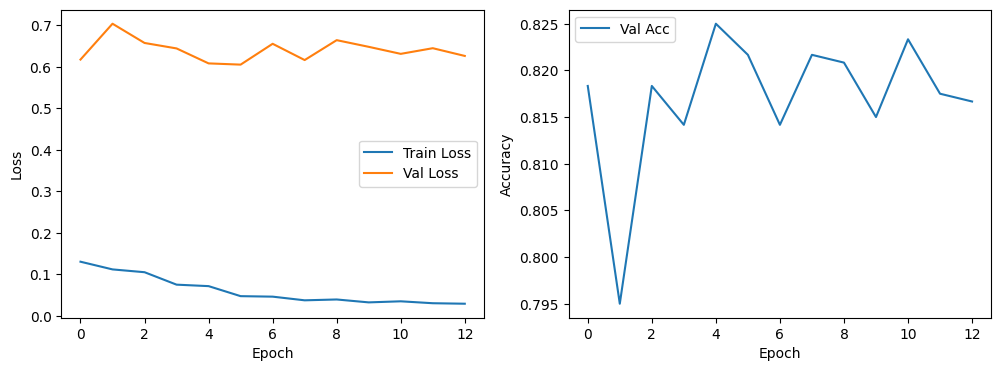

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

Aunque las métricas no son del todo óptimas, se prosigue con la extracción de los kernels, ya que estos no se extraen del val set ni del test set — se extraen directamente de los pesos del modelo. El overfitting afecta la generalización de la clasificación, pero los kernels siguen siendo detectores de texturas y patrones artísticos válidos.

In [ ]:
model.load_state_dict(torch.load("vgg19_wikiart_best.pth"))
model.eval()
print("Modelo cargado ")

Modelo cargado 


                    precision    recall  f1-score   support

     Impressionism       0.89      0.87      0.88       304
            Cubism       0.85      0.87      0.86       311
Art_Nouveau_Modern       0.79      0.84      0.82       284
     Expressionism       0.75      0.71      0.73       301

          accuracy                           0.82      1200
         macro avg       0.82      0.82      0.82      1200
      weighted avg       0.82      0.82      0.82      1200



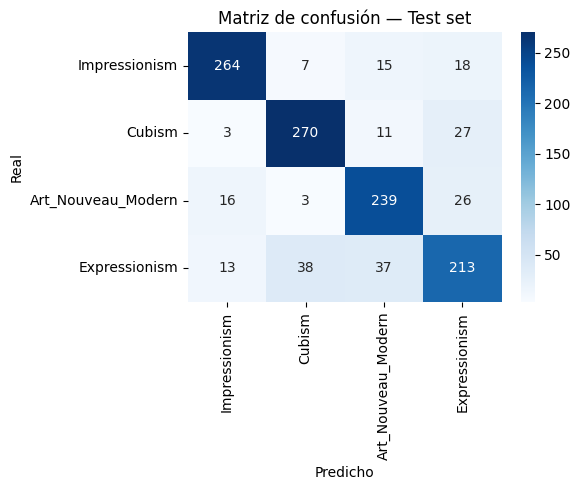

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Cargar mejor modelo
model.load_state_dict(torch.load("vgg19_wikiart_best.pth"))
model.eval()

# Inferencia sobre test set
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Reporte
print(classification_report(all_labels, all_preds, target_names=STYLES))

# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=STYLES, yticklabels=STYLES, cmap="Blues")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.title("Matriz de confusión — Test set")
plt.tight_layout()
plt.show()